# Telecomunicaciones: identificar operadores ineficaces

El servicio de telefonía virtual CallMeMaybe está desarrollando una nueva función que brindará a los supervisores y las supervisores información sobre los operadores menos eficaces. *Se considera que un operador es ineficaz si tiene una gran cantidad de llamadas entrantes perdidas (internas y externas) y un tiempo de espera prolongado para las llamadas entrantes. Además, si se supone que un operador debe realizar llamadas salientes, un número reducido de ellas también será un signo de ineficacia.*

1. Lleva a cabo el análisis exploratorio de datos
2. Identificar operadores ineficaces
3. Prueba las hipótesis estadísticas

### Descripción de los datos

Los datasets contienen información sobre el uso del servicio de telefonía virtual CallMeMaybe. Sus clientes son organizaciones que necesitan distribuir gran cantidad de llamadas entrantes entre varios operadores, o realizar llamadas salientes a través de sus operadores. Los operadores también pueden realizar llamadas internas para comunicarse entre ellos. Estas llamadas se realizan a través de la red de CallMeMaybe.

El dataset comprimido `telecom_dataset_us.csv` contiene las siguientes columnas:

- `user_id`: ID de la cuenta de cliente
- `date`: fecha en la que se recuperaron las estadísticas
- `direction`: "dirección" de llamada (`out` para saliente, `in` para entrante)
- `internal`: si la llamada fue interna (entre los operadores de un cliente o clienta)
- `operator_id`: identificador del operador
- `is_missed_call`: si fue una llamada perdida
- `calls_count`: número de llamadas
- `call_duration`: duración de la llamada (sin incluir el tiempo de espera)
- `total_call_duration`: duración de la llamada (incluido el tiempo de espera)

 

El conjunto de datos `telecom_clients_us.csv` tiene las siguientes columnas:

- `user_id`: ID de usuario/a
- `tariff_plan`: tarifa actual de la clientela
- `date_start`: fecha de registro de la clientela

## 1. Análisis exploratorío de datos 

In [114]:
# Librerías 
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [115]:
# Importamos los datos
dataset = pd.read_csv('Datasets/telecom_dataset_new.csv')
clients = pd.read_csv('Datasets/telecom_clients.csv')


### Análisis del DataFrame 'dataset'

In [116]:
dataset.info('deep')

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 53902 entries, 0 to 53901
Data columns (total 9 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   user_id              53902 non-null  int64  
 1   date                 53902 non-null  object 
 2   direction            53902 non-null  object 
 3   internal             53785 non-null  object 
 4   operator_id          45730 non-null  float64
 5   is_missed_call       53902 non-null  bool   
 6   calls_count          53902 non-null  int64  
 7   call_duration        53902 non-null  int64  
 8   total_call_duration  53902 non-null  int64  
dtypes: bool(1), float64(1), int64(4), object(3)
memory usage: 3.3+ MB


In [117]:
dataset.head()

,user_id,date,direction,internal,operator_id,is_missed_call,calls_count,call_duration,total_call_duration
0,166377,2019-08-04 00:00:00+03:00,in,False,NaN,True,2,0,4
1,166377,2019-08-05 00:00:00+03:00,out,True,880022.0,True,3,0,5
2,166377,2019-08-05 00:00:00+03:00,out,True,880020.0,True,1,0,1
3,166377,2019-08-05 00:00:00+03:00,out,True,880020.0,False,1,10,18
4,166377,2019-08-05 00:00:00+03:00,out,False,880022.0,True,3,0,25


Limpiamos los datos:
- Convertimos la columna 'date' a formato Datetime.
- Convertimos la columna 'internal' a Booleano.
- Los valores nulos los vamos a eliminar ya que hayamos juntado los dos datasets y creado una copia.

In [118]:
# Convertimos los datos de la columna 'date' a formato Datetime
dataset['date'] = pd.to_datetime(dataset['date'])

# Convertimos los datos de la columna 'internal' a Booleano
dataset['internal'] = dataset['internal'].astype(bool)

In [119]:
dataset.info('deep')

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 53902 entries, 0 to 53901
Data columns (total 9 columns):
 #   Column               Non-Null Count  Dtype                    
---  ------               --------------  -----                    
 0   user_id              53902 non-null  int64                    
 1   date                 53902 non-null  datetime64[ns, UTC+03:00]
 2   direction            53902 non-null  object                   
 3   internal             53902 non-null  bool                     
 4   operator_id          45730 non-null  float64                  
 5   is_missed_call       53902 non-null  bool                     
 6   calls_count          53902 non-null  int64                    
 7   call_duration        53902 non-null  int64                    
 8   total_call_duration  53902 non-null  int64                    
dtypes: bool(2), datetime64[ns, UTC+03:00](1), float64(1), int64(4), object(1)
memory usage: 3.0+ MB


In [120]:
dataset.head()

,user_id,date,direction,internal,operator_id,is_missed_call,calls_count,call_duration,total_call_duration
0,166377,2019-08-04 00:00:00+03:00,in,False,NaN,True,2,0,4
1,166377,2019-08-05 00:00:00+03:00,out,True,880022.0,True,3,0,5
2,166377,2019-08-05 00:00:00+03:00,out,True,880020.0,True,1,0,1
3,166377,2019-08-05 00:00:00+03:00,out,True,880020.0,False,1,10,18
4,166377,2019-08-05 00:00:00+03:00,out,False,880022.0,True,3,0,25


### Análisis del DataFrame 'clients'

In [121]:
clients.info('deep')

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 732 entries, 0 to 731
Data columns (total 3 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   user_id      732 non-null    int64 
 1   tariff_plan  732 non-null    object
 2   date_start   732 non-null    object
dtypes: int64(1), object(2)
memory usage: 17.3+ KB


In [122]:
clients.head()

,user_id,tariff_plan,date_start
0,166713,A,2019-08-15
1,166901,A,2019-08-23
2,168527,A,2019-10-29
3,167097,A,2019-09-01
4,168193,A,2019-10-16


Limpiamos los datos:
- Convertimos la columna 'date_start' a tipo Datetime.

In [123]:
clients['date_start'] = pd.to_datetime(clients['date_start'])

print(clients.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 732 entries, 0 to 731
Data columns (total 3 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   user_id      732 non-null    int64         
 1   tariff_plan  732 non-null    object        
 2   date_start   732 non-null    datetime64[ns]
dtypes: datetime64[ns](1), int64(1), object(1)
memory usage: 17.3+ KB
None


### Combinamos los dos DataFrames para facilitar el análisis futuro

In [124]:
# Utilizamos merge() para combinarlos
df = dataset.merge(clients)

print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 53902 entries, 0 to 53901
Data columns (total 11 columns):
 #   Column               Non-Null Count  Dtype                    
---  ------               --------------  -----                    
 0   user_id              53902 non-null  int64                    
 1   date                 53902 non-null  datetime64[ns, UTC+03:00]
 2   direction            53902 non-null  object                   
 3   internal             53902 non-null  bool                     
 4   operator_id          45730 non-null  float64                  
 5   is_missed_call       53902 non-null  bool                     
 6   calls_count          53902 non-null  int64                    
 7   call_duration        53902 non-null  int64                    
 8   total_call_duration  53902 non-null  int64                    
 9   tariff_plan          53902 non-null  object                   
 10  date_start           53902 non-null  datetime64[ns]           
dtypes:

In [125]:
# Creamos una copia para trabajar con ella y borrar los valores ausentes de la columna 'operator_id'
df_copy = df.copy()
df_copy = df_copy.dropna()

# Convertimos a int64 los valores de la columna 'operator_id'
df_copy['operator_id'] = df_copy['operator_id'].astype('int64')

df_copy.info()


<class 'pandas.core.frame.DataFrame'>
Index: 45730 entries, 1 to 53900
Data columns (total 11 columns):
 #   Column               Non-Null Count  Dtype                    
---  ------               --------------  -----                    
 0   user_id              45730 non-null  int64                    
 1   date                 45730 non-null  datetime64[ns, UTC+03:00]
 2   direction            45730 non-null  object                   
 3   internal             45730 non-null  bool                     
 4   operator_id          45730 non-null  int64                    
 5   is_missed_call       45730 non-null  bool                     
 6   calls_count          45730 non-null  int64                    
 7   call_duration        45730 non-null  int64                    
 8   total_call_duration  45730 non-null  int64                    
 9   tariff_plan          45730 non-null  object                   
 10  date_start           45730 non-null  datetime64[ns]           
dtypes: bool

### Decisión de borrar los balores ausente:
La decisión de borrar los valores ausentes la he hecho en la copia para no modificar el DF original.
Debido a que la única columna con valores ausentes es la de los operadores, imposibilita con los datos actuales, identificarlos para saber si son ineficaces o no, entonces he decidido borrarlos y trabajar solo con los que están debidamente identificados.

In [126]:
df_copy.head()

,user_id,date,direction,internal,operator_id,is_missed_call,calls_count,call_duration,total_call_duration,tariff_plan,date_start
1,166377,2019-08-05 00:00:00+03:00,out,True,880022,True,3,0,5,B,2019-08-01
2,166377,2019-08-05 00:00:00+03:00,out,True,880020,True,1,0,1,B,2019-08-01
3,166377,2019-08-05 00:00:00+03:00,out,True,880020,False,1,10,18,B,2019-08-01
4,166377,2019-08-05 00:00:00+03:00,out,False,880022,True,3,0,25,B,2019-08-01
5,166377,2019-08-05 00:00:00+03:00,out,False,880020,False,2,3,29,B,2019-08-01


## 2. Identificar operadores ineficaces

Plan de trabajo para identificar operadores ineficaces:
- Calcular las llamadas perdidas por usuario utilizando groupby().
- Calcular el tiempo de espera restando la columna 'total_call_duration' menos 'call_duration'.
- Sacar conclusiones de los resultados.

In [127]:
# Calculamos las llamadas perdidas que tiene cada operador
missed_calls = df_copy.groupby('operator_id')['is_missed_call'].sum().sort_values(ascending= False)

missed_calls

operator_id
885876    135
891410    131
893804    130
901880    128
891414    126
         ... 
969600      0
966686      0
968232      0
968368      0
968520      0
Name: is_missed_call, Length: 1092, dtype: int64

In [144]:
# Calculamos el tiempo de espera de las llamadas por operador
wait_in = df_copy.loc[df_copy['direction'] == 'in'].copy()
wait_in['wait_call'] = wait_in['total_call_duration'] - wait_in['call_duration']
wait_time = wait_in.groupby('operator_id')['wait_call'].mean().round(1)
wait_in.head()


,user_id,date,direction,internal,operator_id,is_missed_call,calls_count,call_duration,total_call_duration,tariff_plan,date_start,wait_call
26,166377,2019-08-12 00:00:00+03:00,in,False,880028,False,1,407,411,B,2019-08-01,4
34,166377,2019-08-13 00:00:00+03:00,in,False,880028,False,1,88,102,B,2019-08-01,14
37,166377,2019-08-14 00:00:00+03:00,in,False,880026,False,2,197,218,B,2019-08-01,21
39,166377,2019-08-14 00:00:00+03:00,in,False,880028,False,1,33,37,B,2019-08-01,4
49,166377,2019-08-15 00:00:00+03:00,in,False,880028,False,1,23,27,B,2019-08-01,4


In [157]:
# Llamadas contadas por operador
calls_count = df_copy.groupby('operator_id')['calls_count'].sum()

# Llamadas salientes
outbound_calls = df_copy[df_copy['direction'] == 'out'].groupby('operator_id').size()

# Tasa de llamadas salientes
outbound_rate = (outbound_calls / calls_count * 100).round(1)
outbound_rate = outbound_rate[calls_count >= 10]
outbound_rate = outbound_rate.sort_values()

# Total de llamadas
total_calls = df_copy.groupby('operator_id').size()


In [ ]:
# Tasa de llamadas perdidas conciderando a un operador 'activo' con un total de 10 llamadas o más
missed_rate = (missed_calls / calls_count * 100).round(1)
missed_rate = missed_rate[calls_count >= 10]
missed_rate = missed_rate.sort_values(ascending= False)

# Juntamos todo en un dataframe de trabajo con los parámetros que necesitamos
work_df = pd.DataFrame({
    'total_calls': total_calls,
    'outbound_calls': outbound_calls,
    'missed_calls': missed_calls,
    'missed_rate_%': missed_rate,
    'avg_wait_time': wait_time
}).sort_values('missed_rate_%', ascending=False)

print(missed_rate.head(20))

operator_id
953460    70.0
898434    50.0
888406    40.0
933996    40.0
894232    38.1
940788    36.4
918888    36.4
881278    35.0
894230    33.3
894226    32.0
956298    31.2
892800    30.0
939212    30.0
939718    30.0
947610    29.2
891156    29.2
957022    28.6
892530    28.6
906392    27.5
937604    27.0
dtype: float64


In [131]:
# Imprimimos los resultados obtenido
print("Resumen de métricas de ineficacia por operador:")
print(work_df)
print(f"\nPromedio de tasa de pérdida: {missed_rate.mean():.2f}%")
print(f"Promedio de tiempo de espera: {wait_time.mean():.2f} segundos")

Resumen de métricas de ineficacia por operador:
             total_calls  outbound_calls  outbound_rate_%  missed_calls  \
operator_id                                                               
953460                 8             8.0           100.00             7   
898434                 6             6.0           100.00             5   
888406                13             6.0            46.15             6   
933996                12             8.0            66.67             6   
894232                14            10.0            71.43             8   
...                  ...             ...              ...           ...   
971100                 2             NaN              NaN             0   
971354                 2             NaN              NaN             0   
972408                 3             3.0           100.00             2   
973120                 2             2.0           100.00             1   
973286                 1             NaN            

Vamos a visualizar los resultados con gráficos de barras

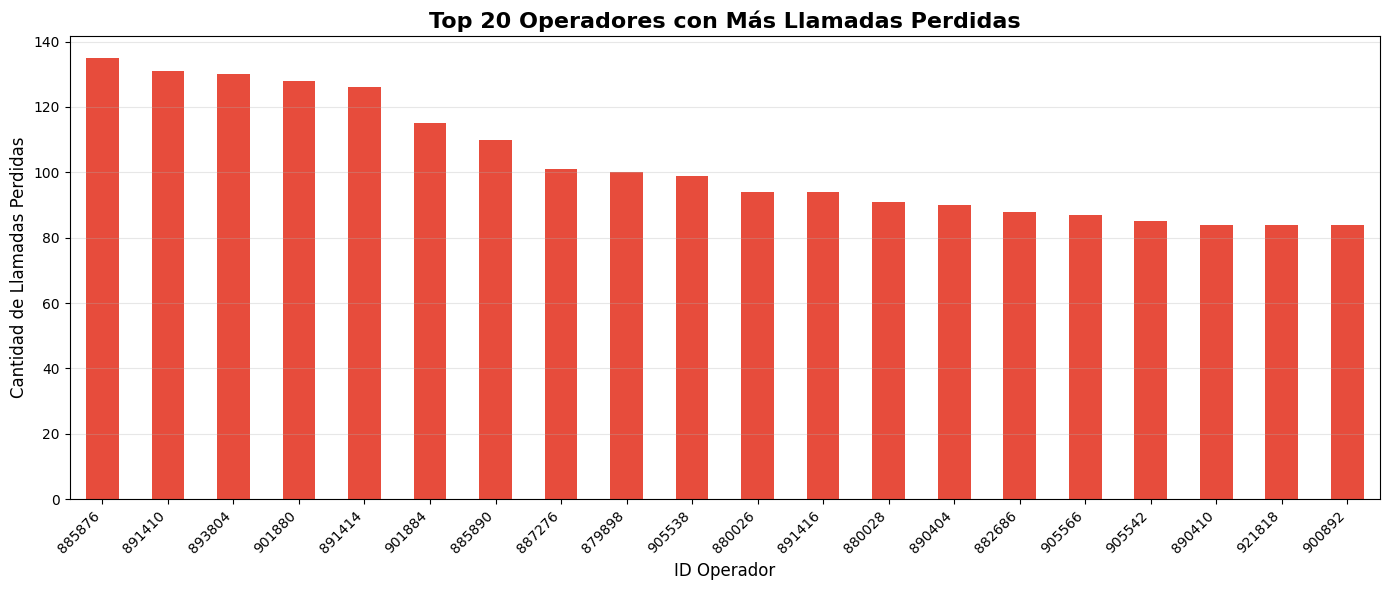

In [132]:
# Llamadas perdidas por operador
plt.figure(figsize=(14, 6))
missed_calls.head(20).plot(kind='bar', color='#e74c3c')
plt.title('Top 20 Operadores con Más Llamadas Perdidas', fontsize=16, fontweight='bold')
plt.xlabel('ID Operador', fontsize=12)
plt.ylabel('Cantidad de Llamadas Perdidas', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()


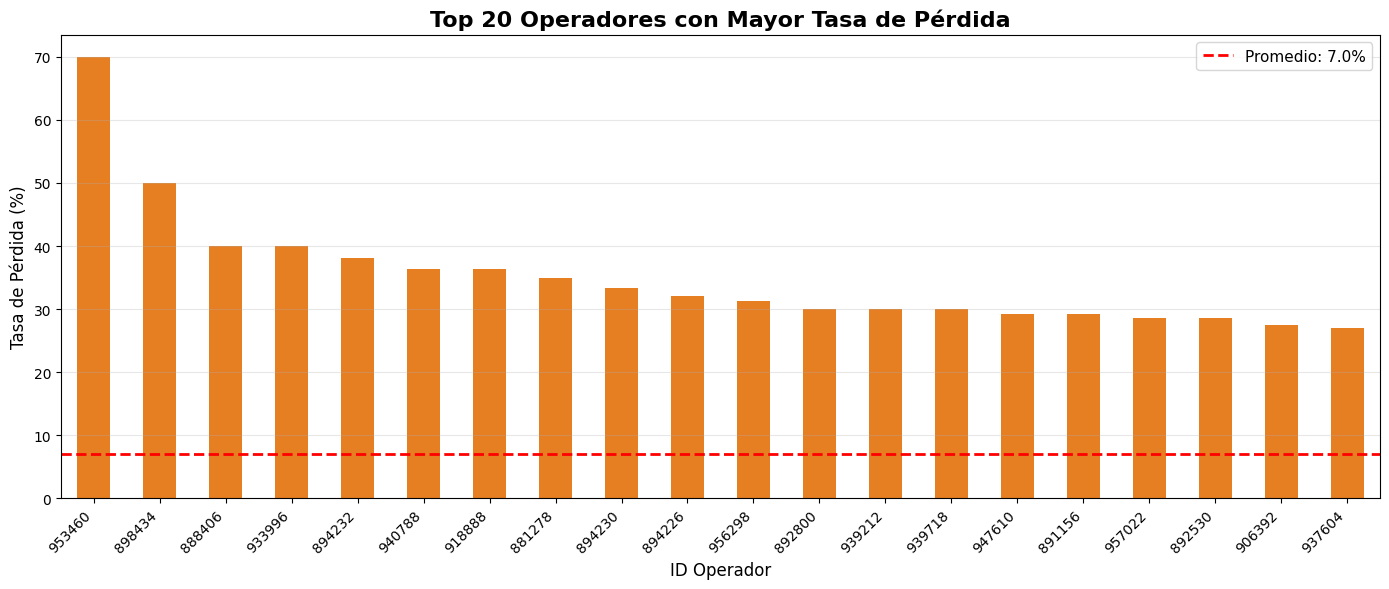

In [133]:
# Tasa de llamadas perdidas por operador
plt.figure(figsize=(14, 6))
missed_rate.head(20).plot(kind='bar', color='#e67e22')
plt.title('Top 20 Operadores con Mayor Tasa de Pérdida', fontsize=16, fontweight='bold')
plt.xlabel('ID Operador', fontsize=12)
plt.ylabel('Tasa de Pérdida (%)', fontsize=12)
plt.axhline(y=missed_rate.mean(), color='red', linestyle='--', 
            linewidth=2, label=f'Promedio: {missed_rate.mean():.1f}%')
plt.xticks(rotation=45, ha='right')
plt.legend(fontsize=11)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

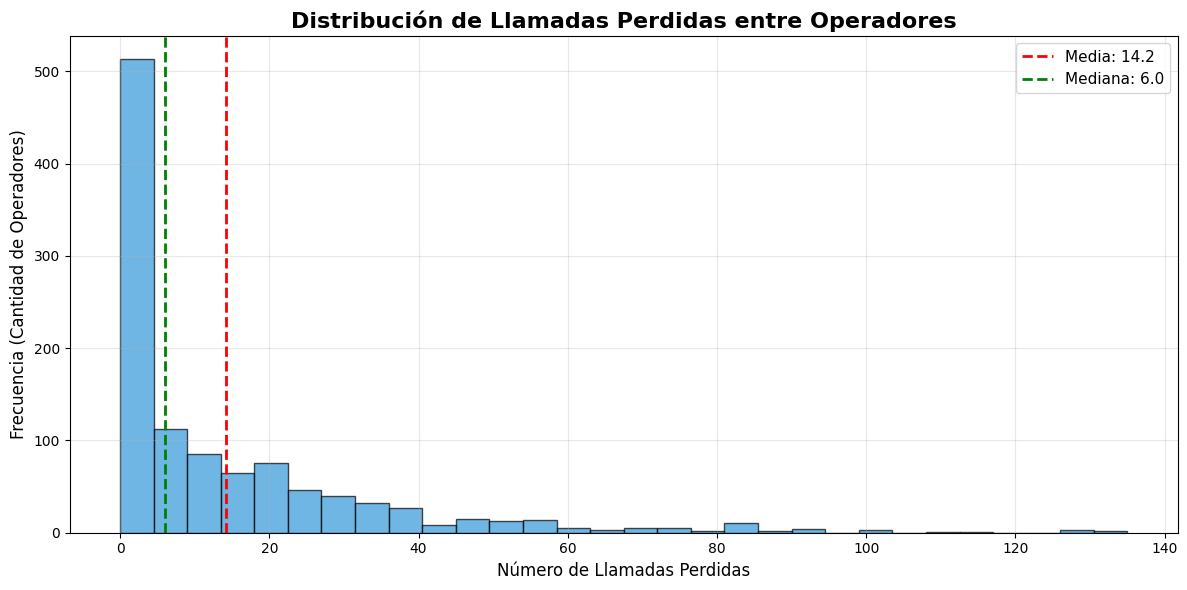

In [134]:
# Distribución de llamadas perdidas
plt.figure(figsize=(12, 6))
plt.hist(missed_calls, bins=30, color='#3498db', edgecolor='black', alpha=0.7)
plt.title('Distribución de Llamadas Perdidas entre Operadores', fontsize=16, fontweight='bold')
plt.xlabel('Número de Llamadas Perdidas', fontsize=12)
plt.ylabel('Frecuencia (Cantidad de Operadores)', fontsize=12)
plt.axvline(missed_calls.mean(), color='red', linestyle='--', 
            linewidth=2, label=f'Media: {missed_calls.mean():.1f}')
plt.axvline(missed_calls.median(), color='green', linestyle='--', 
            linewidth=2, label=f'Mediana: {missed_calls.median():.1f}')
plt.legend(fontsize=11)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

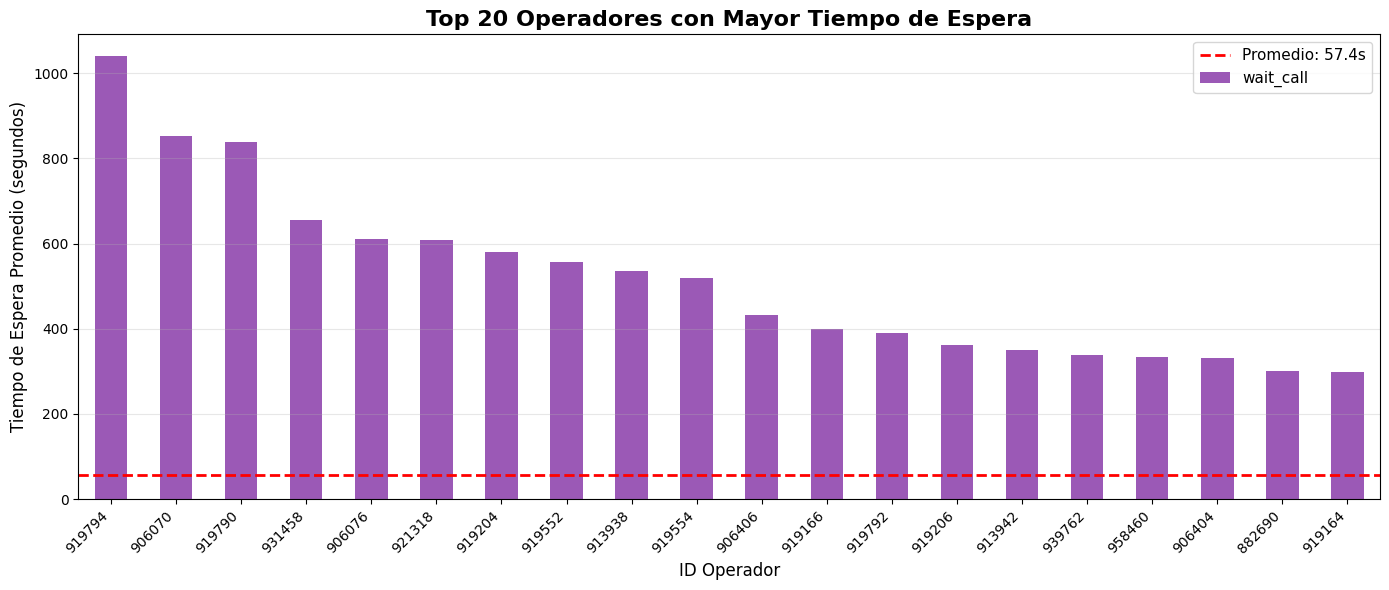

In [145]:
# Tiempo de espera por operador
plt.figure(figsize=(14, 6))
wait_time.sort_values(ascending=False).head(20).plot(kind='bar', color='#9b59b6')
plt.title('Top 20 Operadores con Mayor Tiempo de Espera', fontsize=16, fontweight='bold')
plt.xlabel('ID Operador', fontsize=12)
plt.ylabel('Tiempo de Espera Promedio (segundos)', fontsize=12)
plt.axhline(y=wait_time.mean(), color='red', linestyle='--', 
            linewidth=2, label=f'Promedio: {wait_time.mean():.1f}s')
plt.xticks(rotation=45, ha='right')
plt.legend(fontsize=11)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

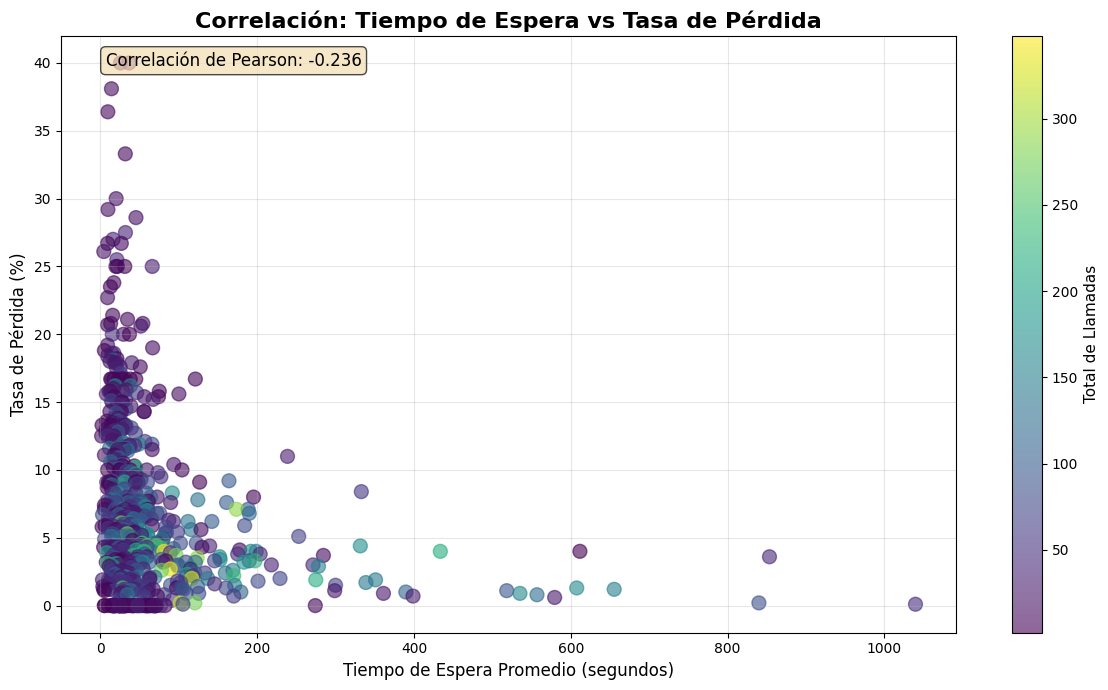

In [147]:
# Correlación entre las llamadas perdidas y el tiempo de espera
plt.figure(figsize=(12, 7))
plot_data = work_df.dropna(subset=['avg_wait_time', 'missed_rate_%'])
scatter = plt.scatter(plot_data['avg_wait_time'], plot_data['missed_rate_%'], 
                      alpha=0.6, c=plot_data['total_calls'], cmap='viridis', s=100)
plt.title('Correlación: Tiempo de Espera vs Tasa de Pérdida', fontsize=16, fontweight='bold')
plt.xlabel('Tiempo de Espera Promedio (segundos)', fontsize=12)
plt.ylabel('Tasa de Pérdida (%)', fontsize=12)
plt.grid(alpha=0.3)
cbar = plt.colorbar(scatter)
cbar.set_label('Total de Llamadas', fontsize=11)

if len(plot_data) > 0:
    correlation = plot_data['avg_wait_time'].corr(plot_data['missed_rate_%'])
    plt.text(0.05, 0.95, f'Correlación de Pearson: {correlation:.3f}', 
             transform=plt.gca().transAxes, fontsize=12,
             bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.7))
plt.tight_layout()
plt.show()

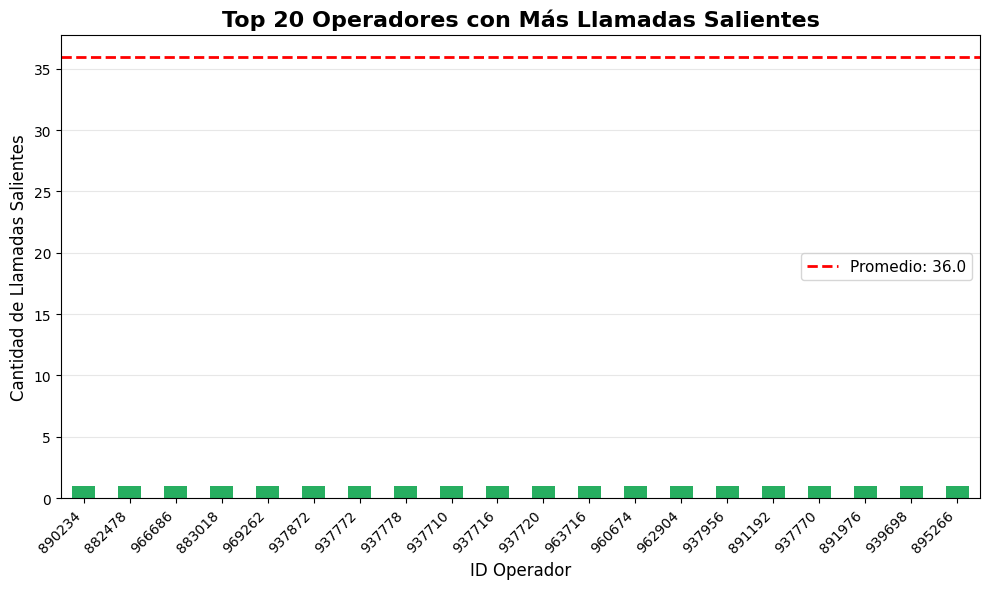

In [162]:
# Llamadas salientes
plt.figure(figsize=(10, 6))
outbound_calls.sort_values(ascending=True).head(20).plot(kind='bar', color='#27ae60')
plt.title('Top 20 Operadores con Más Llamadas Salientes', fontsize=16, fontweight='bold')
plt.xlabel('ID Operador', fontsize=12)
plt.ylabel('Cantidad de Llamadas Salientes', fontsize=12)
plt.axhline(y=outbound_calls.mean(), color='red', linestyle='--', 
            linewidth=2, label=f'Promedio: {outbound_calls.mean():.1f}')
plt.xticks(rotation=45, ha='right')
plt.legend(fontsize=11)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

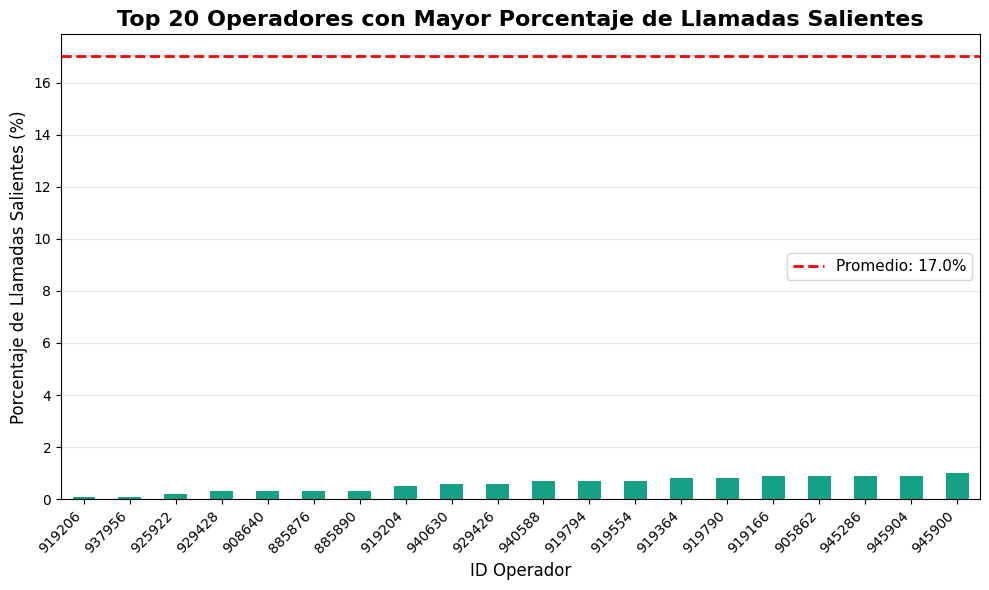

In [161]:
# Tasa de llamadas salientes
plt.figure(figsize=(10, 6))
outbound_rate.sort_values(ascending=True).head(20).plot(kind='bar', color='#16a085')
plt.title('Top 20 Operadores con Mayor Porcentaje de Llamadas Salientes', 
          fontsize=16, fontweight='bold')
plt.xlabel('ID Operador', fontsize=12)
plt.ylabel('Porcentaje de Llamadas Salientes (%)', fontsize=12)
plt.axhline(y=outbound_rate.mean(), color='red', linestyle='--', 
            linewidth=2, label=f'Promedio: {outbound_rate.mean():.1f}%')
plt.xticks(rotation=45, ha='right')
plt.legend(fontsize=11)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

## Conclusiones:
Con un total de 1092 operadores debidadmente registrados con sus ID, obtuvimos las métricas para conocer cuales son los operadores más ineficaces según los siguientes criterios:
#### 1. Operadores con más llamadas perdidas (top 20):
- ID = 885876, 135 llamadas perdidas
- ID = 891410    131, llamadas perdidas
- ID = 893804    130, llamadas perdidas
- ID = 901880    128, llamadas perdidas
- ID = 891414    126, llamadas perdidas
- ID = 901884    115, llamadas perdidas
- ID = 885890    110, llamadas perdidas
- ID = 887276    101, llamadas perdidas
- ID = 879898    100, llamadas perdidas
- ID = 905538     99, llamadas perdidas
- ID = 880026     94, llamadas perdidas
- ID = 891416     94, llamadas perdidas
- ID = 880028     91, llamadas perdidas
- ID = 890404     90, llamadas perdidas
- ID = 882686     88, llamadas perdidas
- ID = 905566     87, llamadas perdidas
- ID = 905542     85, llamadas perdidas
- ID = 890410     84, llamadas perdidas
- ID = 921818     84, llamadas perdidas
- ID = 900892     84, llamadas perdidas

Sin embargo; considero que realmente lo que definiría en este rubro si el operador es ineficas o no es la tasa (%) de llamadas perdidas respecto al total de llamadas contadas individualmente, esto debido a que nos da un mejor entendimiento de la situación rael. Siendo un 7% la tasa de llamadas perdiddas por operador los siguientes 20 se encuentran muy por arriba del promedio. Considerando aquellos operadores que tienen igual o más de 10 llamadas contadas como elementos activos y debidamente registrados, obtenemos que aquellos con la más alta tasa de llamadas perdidas son:
- ID = 953460, con 70.0%
- ID = 898434, con 50.0%
- ID = 888406, con 40.0%
- ID = 933996, con 40.0%
- ID = 894232, con 38.1%
- ID = 940788, con 36.4%
- ID = 918888, con 36.4%
- ID = 881278, con 35.0%
- ID = 894230, con 33.3%
- ID = 894226, con 32.0%
- ID = 956298, con 31.2%
- ID = 892800, con 30.0%
- ID = 939212, con 30.0%
- ID = 939718, con 30.0%
- ID = 947610, con 29.2%
- ID = 891156, con 29.2%
- ID = 957022, con 28.6%
- ID = 892530, con 28.6%
- ID = 906392, con 27.5%
- ID = 937604, con 27.0%

#### 2. Operadores con más tiempo de espera
El top 20 de operadores con promedio de tiempo de espera más alto medido en segundos son los siguientes: 
- ID = 919794,    1039.5 Seg
- ID = 906070,     853.3 Seg
- ID = 919790,     839.8 Seg
- ID = 931458,     655.2 Seg
- ID = 906076,     611.5 Seg
- ID = 921318,     607.5 Seg
- ID = 919204,     579.3 Seg
- ID = 919552,    556.8 Seg
- ID = 913938,     535.0 Seg
- ID = 919554,     518.2 Seg
- ID = 906406,     433.5 Seg
- ID = 919166,    398.6 Seg
- ID = 919792,     389.5 Seg
- ID = 919206,     360.9 Seg
- ID = 913942,     350.9 Seg
- ID = 939762,    338.6 Seg
- ID = 958460,     332.7 Seg 
- ID = 906404,     331.4 Seg
- ID = 882690,     299.8 Seg
- ID = 919164,     298.7 Seg

A simple vista, podemos notar que son diferentes operadores los más altos en la tasa de llamadas perdidas y el promedio de espera para llamadas entrantes, sin embargo, para confirmar que no están relacionados uno con otro y poder descartar que las causas de que este sucediendo una situación o la otra tienen relacionan, calculamos la correlación de Pearson entre ellos, el resultado fue de -0.23, el gráfico nos indica que cuando el tiempo de espera aumenta, las llamadas perdidas tienden a disminuir, pero muy ligeramente, el valor está muy lejos de -1 así que no hay una relación fuerte, el tiempo de espera explica muy poco el comportamiento de las llamadas perdidas.
Puede haber otros factores más influyentes externos.
 
 ### 3. Operadores con más llamadas salientes
 Como último rublo a considerar para catalogar un operador ineficiente son pocas llamadas salientes, sin embargo, en este caso también consideraremos la tasa de llamadas salientes en lugar se solo el número menor de llamadas salientes, y los 20 operadores con menor tasa de llamadas salientes son:
- ID = 919206,    0.1%
- ID = 937956,    0.1%
- ID = 925922,    0.2%
- ID = 929428,    0.3%
- ID = 908640,    0.3%
- ID = 885876,    0.3%
- ID = 885890,    0.3%
- ID = 919204,    0.5%
- ID = 940630,    0.6%
- ID = 929426,    0.6%
- ID = 940588,    0.7%
- ID = 919794,    0.7%
- ID = 919554,    0.7%
- ID = 919364,    0.8%
- ID = 919790,    0.8%
- ID = 919166,    0.9%
- ID = 905862,    0.9%
- ID = 945286,    0.9%
- ID = 945904,    0.9%
- ID = 945900,    1.0%

## 3. Hipótesis estadística